In [300]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install scikit-learn

In [301]:
import numpy as np
from matplotlib import pyplot as plt
import math
import pandas as pd
#from sklearn.preprocessing import StandardScaler
from PIL import Image
import os
from skimage import data, color
import sys
sys.path.append("ProblemiInversi")
import utilities
import operators
import solvers

In [302]:
def bisezione(f, a, b, max_iter=8000, interval_tolerance=1e-5):
    if f(a) * f(b) >= 0:
        if f(a) == 0:
            return a, 0, [a]
        elif f(b) == 0:
            return b, 0, [b]
        elif f(a) * f(b) > 0:
            raise ValueError("f(a) e f(b) devono avere segno opposto")
    storico_iterazioni = []
    for k in range(max_iter):
        #c = (a + b)/2
        c = a + (b - a)/2
        storico_iterazioni.append(c)
        if (f(c) == 0): break
        if f(a)*f(c) < 0:
            b=c
        else:
            a=c
        if abs(b - a)/2 < interval_tolerance:
            break
    return c, k+1, storico_iterazioni

In [303]:
def punto_fisso(g, x0, max_iter=8000, interval_tolerance=1e-6):
    storico_iterazioni = [x0]
    for k in range(max_iter):
        x_k_plus_1 = g(x0)
        storico_iterazioni.append(x_k_plus_1)
        if abs(x_k_plus_1 - x0) < interval_tolerance:
            break
        x0 = x_k_plus_1
    return x_k_plus_1, k+1, storico_iterazioni


In [304]:
def newton(f, df, x0, interval_tolerance=1e-6, tol_on_fx=1e-6, max_iter=10000):
    storico_iterazioni = [x0]
    for k in range(max_iter):
        fx = f(x0)
        if abs(fx) < tol_on_fx:
            break
        dfx = df(x0)
        if dfx == 0:
            raise ValueError("Derivata nulla, non posso continuare")
        x_n = x0 - fx / dfx
        storico_iterazioni.append(x_n)
        if abs(x_n - x0) < interval_tolerance:
            x0 = x_n
            break
        x0 = x_n
    return x0, k+1, storico_iterazioni

$$f(x)=ln(x+1)-x(g(x) = ln(x+1))$$

In [305]:
f1 = lambda x: np.log(x+1) - x*np.log(x+1)
g1 = lambda x: np.log(x+1)
df1 = lambda x: (1 - x)/(x+1) - np.log(x+1)

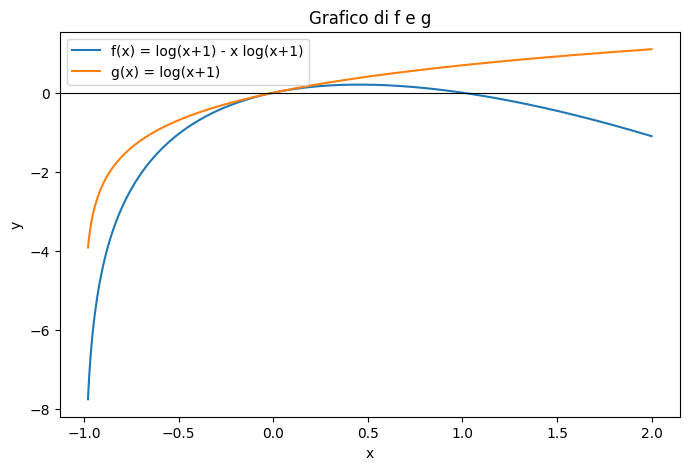

In [306]:
# Dominio (x > -1 per log(x+1))
x = np.linspace(-0.98, 2, 500)

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, f1(x), label='f(x) = log(x+1) - x log(x+1)')
plt.plot(x, g1(x), label='g(x) = log(x+1)')
plt.axhline(0, color='k', linewidth=0.8)  # asse x
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Grafico di f e g')
plt.show()


1.014709472656548e-05 1.0146940282038362e-05


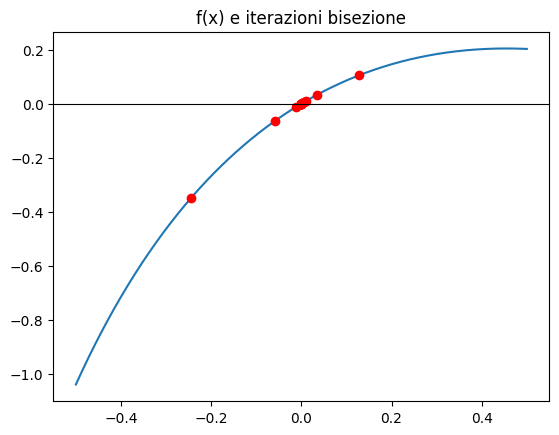

In [307]:
x = np.linspace(-0.5, 0.5, 500)
plt.plot(x, f1(x), label='f(x) = log(x+1) - x log(x+1)')
points = [(-0.99, 0.5)]
for a,b in points:
    c_finale, n_iterazioni, storico_iterazioni = bisezione(f1, a, b, max_iter=8000, interval_tolerance=1e-5)
    print(c_finale, f1(c_finale))
    for xi in storico_iterazioni:
        plt.plot(xi, f1(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni bisezione')
plt.show()


0.004462077173068915 0.004432285777363848


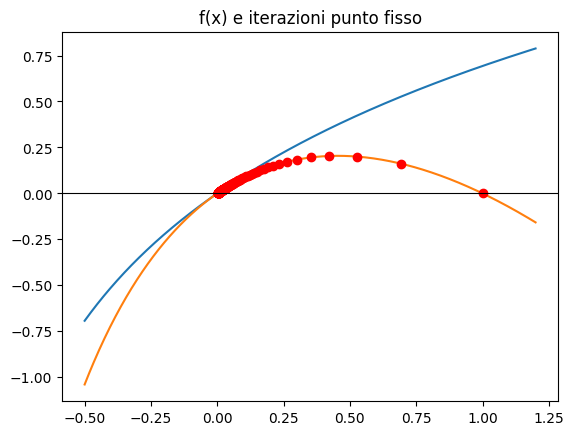

In [308]:
x = np.linspace(-0.5, 1.2, 500)
plt.plot(x, g1(x), label='g(x) = log(x+1)')
plt.plot(x, f1(x), label='f(x) = log(x+1) - x log(x+1)')
c_finale, n_iterazioni, storico_iterazioni = punto_fisso(g1, x0=1, max_iter=8000, interval_tolerance=1e-5)
print(c_finale, f1(c_finale))
for xi in storico_iterazioni:
    plt.plot(xi, f1(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni punto fisso')
plt.show()

1.000000000407095 -2.8217672642938396e-10


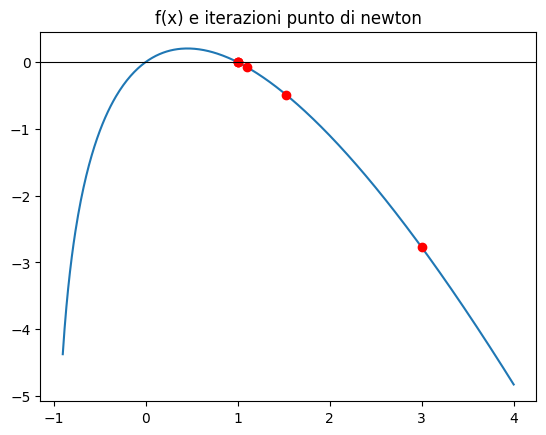

In [309]:
x = np.linspace(-0.9, 4, 500)
plt.plot(x, f1(x), label='f(x) = log(x+1) - x log(x+1)')
c_finale, n_iterazioni, storico_iterazioni = newton(f1, df1, x0=3, interval_tolerance=1e-6, tol_on_fx=1e-6, max_iter=8000)
print(c_finale, f1(c_finale))
for xi in storico_iterazioni:
    plt.plot(xi, f1(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni punto di newton')
plt.show()

In [310]:
points = [1, 10, 100]
max_iters = [800, 400, 100]
for max_iter in max_iters:
    for x0 in points:
        c_finale, n_iterazioni, storico_iterazioni = punto_fisso(g1, x0, max_iter, interval_tolerance=1e-5)
        print(f"x0={x0:5} | Punto fisso (x finale)={c_finale:12.6f} | Iterazioni={n_iterazioni:8}")

x0=    1 | Punto fisso (x finale)=    0.004462 | Iterazioni=     448
x0=   10 | Punto fisso (x finale)=    0.004466 | Iterazioni=     450
x0=  100 | Punto fisso (x finale)=    0.004462 | Iterazioni=     451
x0=    1 | Punto fisso (x finale)=    0.004997 | Iterazioni=     400
x0=   10 | Punto fisso (x finale)=    0.005027 | Iterazioni=     400
x0=  100 | Punto fisso (x finale)=    0.005035 | Iterazioni=     400
x0=    1 | Punto fisso (x finale)=    0.019857 | Iterazioni=     100
x0=   10 | Punto fisso (x finale)=    0.020346 | Iterazioni=     100
x0=  100 | Punto fisso (x finale)=    0.020466 | Iterazioni=     100


In [311]:
points = [1, 10, 100]
tolerances = [1e-10, 1e-8, 1e-6]
for tolerance in tolerances:
            for x0 in points:
                c_finale, n_iterazioni, storico_iterazioni = newton(f1, df1, x0, interval_tolerance=tolerance, tol_on_fx=1e-10, max_iter=100)
                print(f"x0={x0:6} | Netwon={c_finale:12.6f} | Iterazioni={n_iterazioni:7} | Tol.={tolerance}")

x0=     1 | Netwon=    1.000000 | Iterazioni=      1 | Tol.=1e-10
x0=    10 | Netwon=    1.000000 | Iterazioni=      8 | Tol.=1e-10
x0=   100 | Netwon=    1.000000 | Iterazioni=      9 | Tol.=1e-10
x0=     1 | Netwon=    1.000000 | Iterazioni=      1 | Tol.=1e-08
x0=    10 | Netwon=    1.000000 | Iterazioni=      7 | Tol.=1e-08
x0=   100 | Netwon=    1.000000 | Iterazioni=      9 | Tol.=1e-08
x0=     1 | Netwon=    1.000000 | Iterazioni=      1 | Tol.=1e-06
x0=    10 | Netwon=    1.000000 | Iterazioni=      7 | Tol.=1e-06
x0=   100 | Netwon=    1.000000 | Iterazioni=      8 | Tol.=1e-06


$$f(x)=x^2 - cos(x)(g(x) = \sqrt(cos(x)))$$

In [312]:
f2 = lambda x: x**2 - np.cos(x)*np.sqrt(np.cos(x))
g2 = lambda x: np.sqrt(np.cos(x))
df2 = lambda x: 2*x + np.sin(x)*np.sqrt(np.cos(x)) + (np.cos(x)*np.sin(x))/(2*np.sqrt(np.cos(x)))

/tmp/ipykernel_2906/4125914184.py:1: RuntimeWarning: invalid value encountered in sqrt
  f2 = lambda x: x**2 - np.cos(x)*np.sqrt(np.cos(x))
/tmp/ipykernel_2906/4125914184.py:2: RuntimeWarning: invalid value encountered in sqrt
  g2 = lambda x: np.sqrt(np.cos(x))


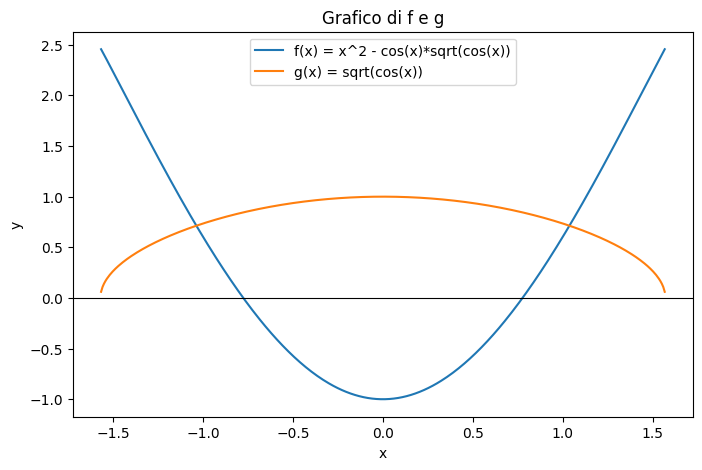

In [313]:
x = np.linspace(-2, 2, 500)

plt.figure(figsize=(8,5))
plt.plot(x, f2(x), label='f(x) = x^2 - cos(x)*sqrt(cos(x))')
plt.plot(x, g2(x), label='g(x) = sqrt(cos(x))')
plt.axhline(0, color='k', linewidth=0.8)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Grafico di f e g')
plt.show()


0.7763214111328125 -5.552354235827117e-06


/tmp/ipykernel_2906/4125914184.py:1: RuntimeWarning: invalid value encountered in sqrt
  f2 = lambda x: x**2 - np.cos(x)*np.sqrt(np.cos(x))


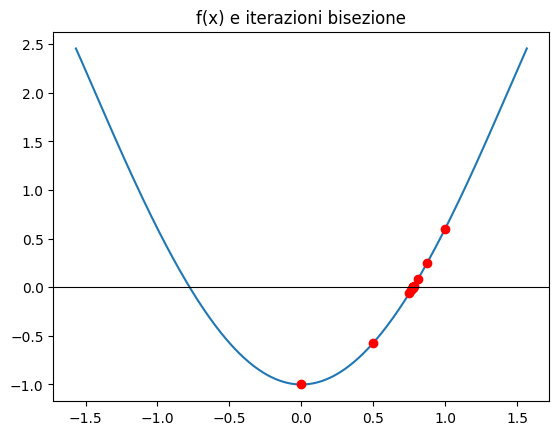

In [314]:
plt.plot(x, f2(x), label='f(x) = x^2 - cos(x)*sqrt(cos(x))')
points = [(-2, 2)]
for a,b in points:
    c_finale, n_iterazioni, storico_iterazioni = bisezione(f2, a, b, max_iter=8000, interval_tolerance=1e-5)
    print(c_finale, f2(c_finale))
    for xi in storico_iterazioni:
        plt.plot(xi, f2(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni bisezione')
plt.show()


0.8241346118528141 0.11945416696734856


/tmp/ipykernel_2906/4125914184.py:1: RuntimeWarning: invalid value encountered in sqrt
  f2 = lambda x: x**2 - np.cos(x)*np.sqrt(np.cos(x))
/tmp/ipykernel_2906/4125914184.py:2: RuntimeWarning: invalid value encountered in sqrt
  g2 = lambda x: np.sqrt(np.cos(x))


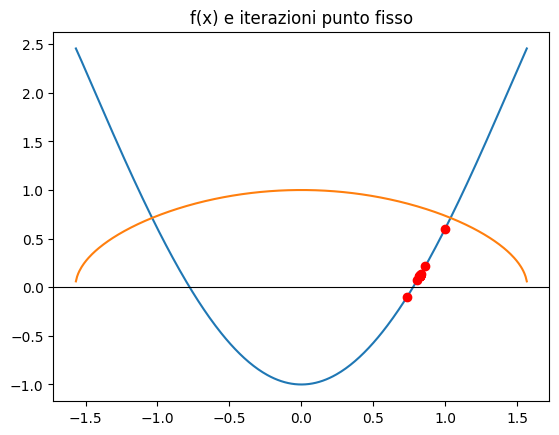

In [315]:
plt.plot(x, f2(x), label='f(x) = x^2 - cos(x)*sqrt(cos(x))')
plt.plot(x, g2(x), label='g(x) = sqrt(cos(x))')
c_finale, n_iterazioni, storico_iterazioni = punto_fisso(g2, x0=1, max_iter=8000, interval_tolerance=1e-5)
print(c_finale, f2(c_finale))
for xi in storico_iterazioni:
    plt.plot(xi, f2(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni punto fisso')
plt.show()

/tmp/ipykernel_2906/4125914184.py:1: RuntimeWarning: invalid value encountered in sqrt
  f2 = lambda x: x**2 - np.cos(x)*np.sqrt(np.cos(x))


0.7763236863144727 4.5288217620509386e-12


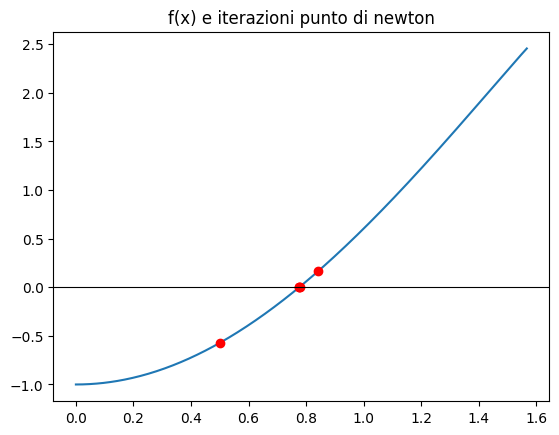

In [316]:
x = np.linspace(0, 2, 500)
plt.plot(x, f2(x), label='f(x) = x^2 - cos(x)*sqrt(cos(x))')
c_finale, n_iterazioni, storico_iterazioni = newton(f2, df2, x0=0.5, interval_tolerance=1e-6, tol_on_fx=1e-6, max_iter=8000)
print(c_finale, f2(c_finale))
for xi in storico_iterazioni:
    plt.plot(xi, f2(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni punto di newton')
plt.show()

$$f(x)=sin(x)-\frac{x}{2}(g(x) = 2sin(x))$$

In [317]:
f3 = lambda x: np.sin(x) - x*np.sin(x)
g3 = lambda x: 2*np.sin(x)
df3 = lambda x: (1-x)*np.cos(x) - np.sin(x)

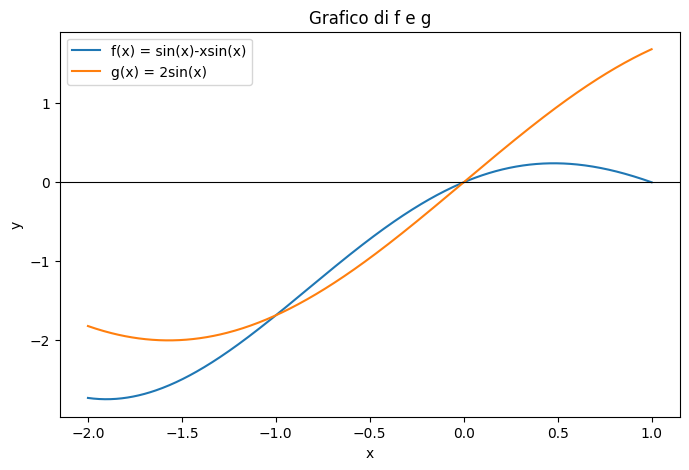

In [318]:
x = np.linspace(-2, 1, 500)

plt.figure(figsize=(8,5))
plt.plot(x, f3(x), label='f(x) = sin(x)-xsin(x)')
plt.plot(x, g3(x), label='g(x) = 2sin(x)')
plt.axhline(0, color='k', linewidth=0.8)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Grafico di f e g')
plt.show()


-3.814697265625e-06 -3.814711817530976e-06


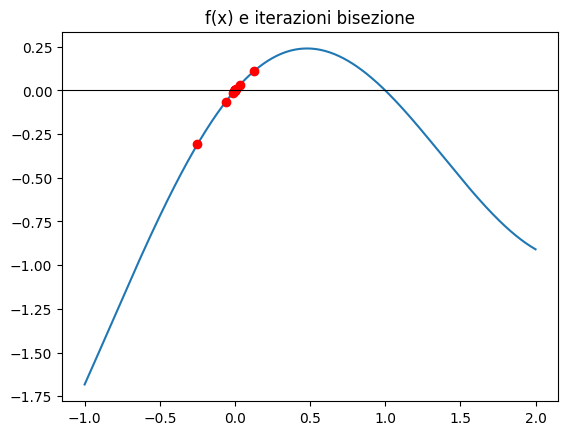

In [319]:
x = np.linspace(-1, 2, 400) 
plt.plot(x, f3(x), label='f(x) = sin(x)-xsin(x)')
points = [(-1, 0.5)]
for a,b in points:
    c_finale, n_iterazioni, storico_iterazioni = bisezione(f3, a, b, max_iter=8000, interval_tolerance=1e-5)
    print(c_finale, f3(c_finale))
    for xi in storico_iterazioni:
        plt.plot(xi, f3(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni bisezione')
plt.show()


1.8954942703331206 -0.8487021268465964
Derivata g'(x*)=2 (<1)


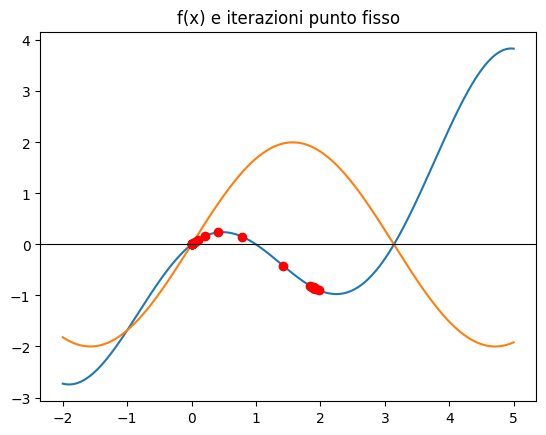

In [320]:
x = np.linspace(-2, 5, 500)
plt.plot(x, f3(x), label='f(x) = sin(x)-xsin(x)')
plt.plot(x, g3(x), label='g(x) = 2sin(x)')
c_finale, n_iterazioni, storico_iterazioni = punto_fisso(g3, x0=0.0001, max_iter=8000, interval_tolerance=1e-8)
print(c_finale, f3(c_finale))
print("Derivata g'(x*)=2 (<1)")
for xi in storico_iterazioni:
    plt.plot(xi, f3(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni punto fisso')
plt.show()

1.0000000206362472 -1.7364803484021252e-08


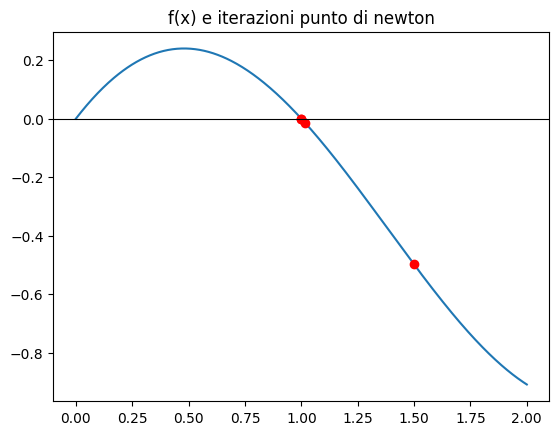

In [321]:
x = np.linspace(0, 2, 500)
plt.plot(x, f3(x), label='f(x) = sin(x)-xsin(x)')
c_finale, n_iterazioni, storico_iterazioni = newton(f3, df3, x0=1.5, interval_tolerance=1e-6, tol_on_fx=1e-6, max_iter=8000)
print(c_finale, f3(c_finale))
for xi in storico_iterazioni:
    plt.plot(xi, f3(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni punto di newton')
plt.show()

$$f(x)= e^x -3x (g(x) = \frac{1}{3}e^x)$$

In [322]:
f4 = lambda x: np.e**x - 3*x*(1/3*np.e**x)
g4 = lambda x: (1/3)*np.e**x
df4 = lambda x: np.e**x - 3*( (1/3*np.e**x) + x*(1/3*np.e**x) )

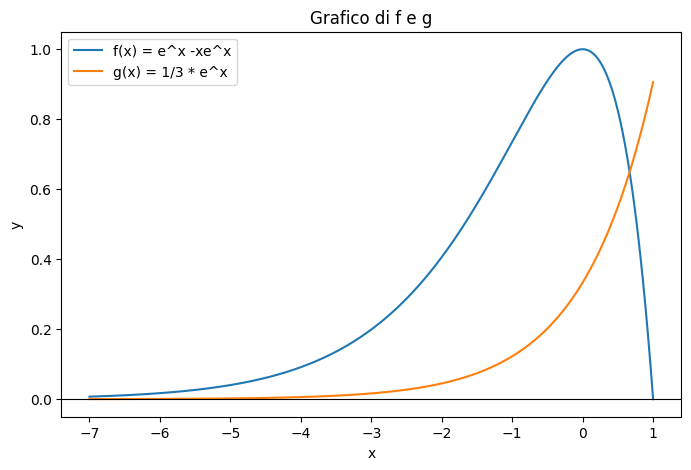

In [323]:
x = np.linspace(-7, 1, 500)

plt.figure(figsize=(8,5))
plt.plot(x, f4(x), label='f(x) = e^x -xe^x')
plt.plot(x, g4(x), label='g(x) = 1/3 * e^x')
plt.axhline(0, color='k', linewidth=0.8)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Grafico di f e g')
plt.show()


0.9999961853027344 1.0369382702268837e-05


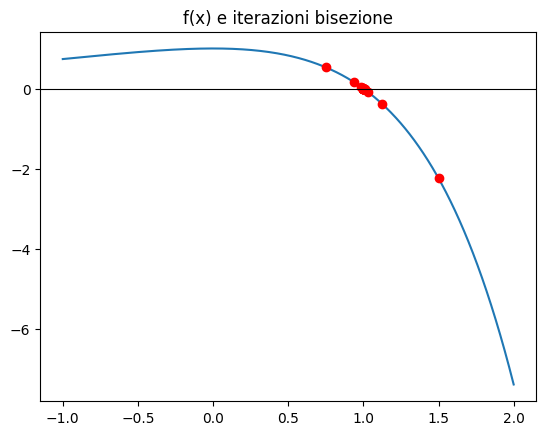

In [324]:
x = np.linspace(-1, 2, 500)
plt.plot(x, f4(x), label='f(x) = e^x -xe^x')
points = [(0, 3)]
for a,b in points:
    c_finale, n_iterazioni, storico_iterazioni = bisezione(f4, a, b, max_iter=8000, interval_tolerance=1e-5)
    print(c_finale, f4(c_finale))
    for xi in storico_iterazioni:
        plt.plot(xi, f4(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni bisezione')
plt.show()

0.6190612765560569 0.7074732417062688
Derivata g'(x*=1)=0.90 != 1


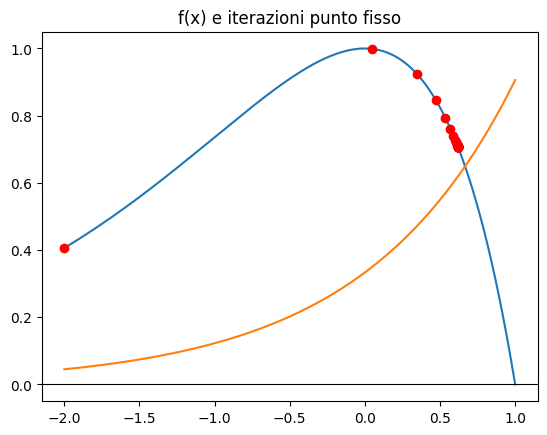

In [325]:
x = np.linspace(-2, 1, 500)
plt.plot(x, f4(x), label='f(x) = e^x -xe^x')
plt.plot(x, g4(x), label='g(x) = 1/3 * e^x')
c_finale, n_iterazioni, storico_iterazioni = punto_fisso(g4, x0=-2, max_iter=8000, interval_tolerance=1e-8)
print(c_finale, f4(c_finale))
print("Derivata g'(x*=1)=0.90 != 1")
for xi in storico_iterazioni:
    plt.plot(xi, f4(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni punto fisso')
plt.show()

1.000000306424934 -8.329495848613533e-07


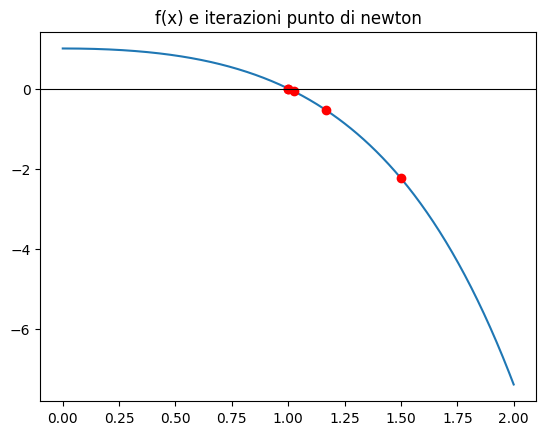

In [326]:
x = np.linspace(0, 2, 500)
plt.plot(x, f4(x), label='f(x) = sin(x)-xsin(x)')
c_finale, n_iterazioni, storico_iterazioni = newton(f4, df4, x0=1.5, interval_tolerance=1e-6, tol_on_fx=1e-6, max_iter=8000)
print(c_finale, f4(c_finale))
for xi in storico_iterazioni:
    plt.plot(xi, f4(xi), 'ro')
plt.axhline(0, color='k', linewidth=0.8)
plt.title('f(x) e iterazioni punto di newton')
plt.show()

HW2

$$f(x_1, x_2) = (x_1 - 5)^2 + (x_2 -2)^2$$

In [327]:
def GD_fisso(f, df, x0, alpha, maxit=8000, tol_grad=1e-6, tol_diff_iter=1e-5):
    """
    Implementazione del metodo di discesa del gradiente multivariabile con passo fisso.
    
    Parameters:
    f (function): funzione obiettivo
    df (function): lista delle derivate della funzione
    x0 (ndarray): lista dei valori iniziali
    alpha (float): passo fisso
    maxit (int): numero di iterazioni
    tol_grad (float): tolleranza sul gradiente
    tol_diff_iter (float): tolleranza sulla differenza di iterazione
    """
    storico_iterazioni = [x0.copy()] 
    xk = np.array(x0, float) #facciamo una copia della lista input
    for iter in range(maxit):
        grad = [g(*xk) for g in df] #lista dei valori dei gradienti gia calcolato rispetto alle incognite
        #cicliamo tutte le incognite
        for i in range(len(xk)): 
            xk[i] = xk[i] - alpha * grad[i]
        norma2_grad = math.sqrt(sum(g**2 for g in grad))
        #controllo tolleranza sul gradiente
        if(norma2_grad < tol_grad): break
        #controllo tolleranza sulla norma della differenza del punto attuale e di quello precedentemente calcolato
        if (np.linalg.norm(xk - x0) < tol_diff_iter): break
        x0 = xk.copy()
        storico_iterazioni.append(xk.copy())
    return xk, iter, np.array(storico_iterazioni)

In [328]:
f = lambda x1, x2: (x1 - 5)**2 + (x2-2)**2
df = [
    lambda x1, x2: 2 * (x1 - 5),  # df/dx1
    lambda x1, x2: 2 * (x2 - 2)   # df/dx2
]

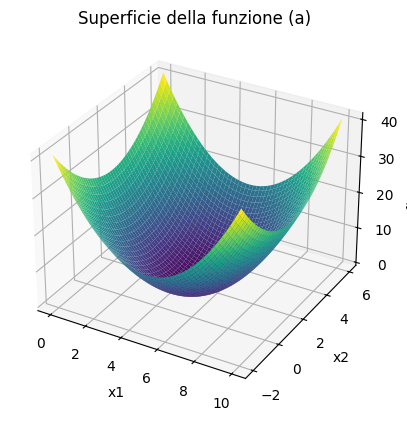

In [329]:
x1 = np.linspace(0, 10, 200)
x2 = np.linspace(-2, 6, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = f(X1, X2)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Z, cmap='viridis')

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1,x2)")
plt.title("Superficie della funzione (a)")

plt.show()
plt.close()

In [330]:
x0_list = [[0, 0], [1, 1], [-1, -1]]
alphas = [0.001, 0.01, 0.05, 0.1]

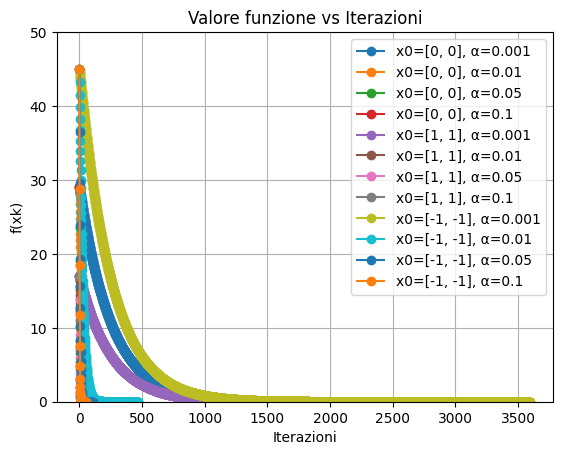

In [331]:
plt.ylim(0, 50)  # zoom sull'asse y

# Grafico funzione vs iterazioni
for x0 in x0_list:
    for a in alphas:
        xk, n_iterazioni, storico_iterazioni = GD_fisso(f, df, x0, a, 4000)
        if not (np.isnan(xk[0]) or np.isnan(xk[1])):
            # Calcolo f(xk) per ogni iterazione
            f_values = [f(*x) for x in storico_iterazioni]
            plt.plot(range(len(f_values)), f_values, marker="o", label=f"x0={x0}, α={a}")

plt.xlabel("Iterazioni")
plt.ylabel("f(xk)")
plt.title("Valore funzione vs Iterazioni")
plt.grid(True)
plt.legend()
plt.show()


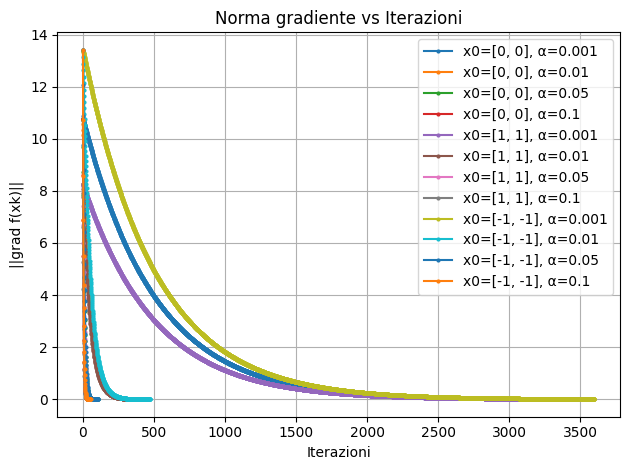

In [332]:
# Grafico norma gradiente vs iterazioni
for x0 in x0_list:
    for a in alphas:
        xk, n_iterazioni, storico_iterazioni = GD_fisso(f, df, x0, a, 4000)
        if not (np.isnan(xk[0]) or np.isnan(xk[1])):
            grad_norms = np.array(
                [np.linalg.norm(
                    [df[0](*x), 
                     df[1](*x)]
                     ) for x in storico_iterazioni])
            plt.plot(range(len(grad_norms)), grad_norms, marker="o", markersize=2, label=f"x0={x0}, α={a}")
plt.xlabel("Iterazioni")
plt.ylabel("||grad f(xk)||")
plt.title("Norma gradiente vs Iterazioni")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

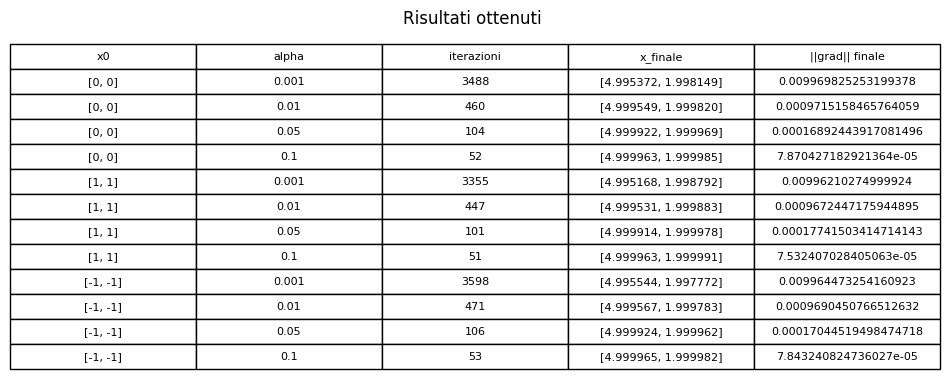

In [333]:
results = []
for x0 in x0_list:
    for a in alphas:
        xk, n_iterazioni, storico_iterazioni = GD_fisso(f, df, x0, a, 4000)
        grad_final = np.linalg.norm([
            df[0](*xk),
            df[1](*xk)
        ])
        results.append({
            "x0": str(x0),
            "alpha": a,
            "iterazioni": n_iterazioni,
            "x_finale": f"[{xk[0]:.6f}, {xk[1]:.6f}]",
            "||grad|| finale": grad_final,
        })
df_results = pd.DataFrame(results)
# Salva tabella 
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
table = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)
plt.title("Risultati ottenuti \n")
plt.show()
plt.close()

$$f(x_1, x_2) = (1-x_1)^2 + 100(x_2 - x_1^2)^2$$

In [334]:
# Funzione di Rosenbrock
f = lambda x1, x2: (1 - x1)**2 + 100*(x2 - x1**2)**2
df = [
    lambda x1, x2: 2*(x1 - 1) - 400*x1*(x2 - x1**2),  # df/dx1
    lambda x1, x2: 200*(x2 - x1**2)                   # df/dx2
]

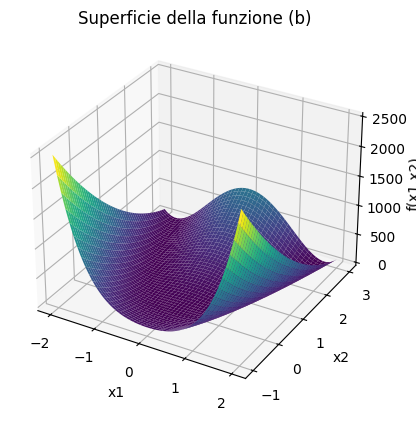

In [335]:
x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-1, 3, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = f(X1, X2)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Z, cmap='viridis')

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1,x2)")
plt.title("Superficie della funzione (b)")
plt.show()
plt.close()

In [336]:
x0_list = [[0, 2], [5, 5]]
alphas = [0.01, 0.005, 0.001]

/tmp/ipykernel_2906/3363138732.py:4: RuntimeWarning: overflow encountered in scalar multiply
  lambda x1, x2: 2*(x1 - 1) - 400*x1*(x2 - x1**2),  # df/dx1
/tmp/ipykernel_2906/4150966150.py:21: RuntimeWarning: overflow encountered in scalar power
  norma2_grad = math.sqrt(sum(g**2 for g in grad))
/home/nico/uni/2/calcolo_num/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/tmp/ipykernel_2906/4150966150.py:20: RuntimeWarning: invalid value encountered in scalar subtract
  xk[i] = xk[i] - alpha * grad[i]
/tmp/ipykernel_2906/3363138732.py:2: RuntimeWarning: overflow encountered in scalar power
  f = lambda x1, x2: (1 - x1)**2 + 100*(x2 - x1**2)**2
/tmp/ipykernel_2906/3363138732.py:4: RuntimeWarning: overflow encountered in scalar power
  lambda x1, x2: 2*(x1 - 1) - 400*x1*(x2 - x1**2),  # df/dx1
/tmp/ipykernel_2906/3363138732.py:5: RuntimeWarning: overflow encountered in scalar power
  lambda x1, x2: 200*(x2 - 

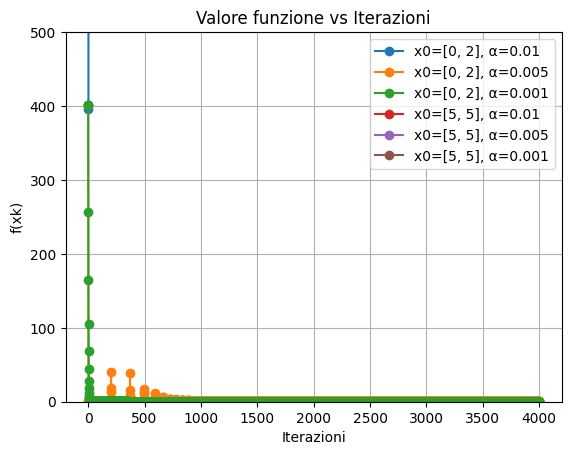

In [337]:
plt.ylim(0, 500)  # zoom sull'asse y

# Grafico funzione vs iterazioni
for x0 in x0_list:
    for a in alphas:
        xk, n_iterazioni, storico_iterazioni = GD_fisso(f, df, x0, a, 4000)
        f_values = []
        for k, x in enumerate(storico_iterazioni):
            try:
                val = f(*x)
                f_values.append(val)
            except (OverflowError, FloatingPointError):
                print(f"Interruzione: overflow a iterazione {k}, x={x}")
                break  # interrompe il ciclo per evitare valori infiniti/NaN

        if f_values:  # plot solo se ci sono valori validi
            plt.plot(range(len(f_values)), f_values, marker="o", label=f"x0={x0}, α={a}")
plt.xlabel("Iterazioni")
plt.ylabel("f(xk)")
plt.title("Valore funzione vs Iterazioni")
plt.grid(True)
plt.legend()
plt.show()


/tmp/ipykernel_2906/3363138732.py:4: RuntimeWarning: overflow encountered in scalar multiply
  lambda x1, x2: 2*(x1 - 1) - 400*x1*(x2 - x1**2),  # df/dx1
/tmp/ipykernel_2906/4150966150.py:21: RuntimeWarning: overflow encountered in scalar power
  norma2_grad = math.sqrt(sum(g**2 for g in grad))
/tmp/ipykernel_2906/4150966150.py:20: RuntimeWarning: invalid value encountered in scalar subtract
  xk[i] = xk[i] - alpha * grad[i]
/tmp/ipykernel_2906/3363138732.py:4: RuntimeWarning: overflow encountered in scalar power
  lambda x1, x2: 2*(x1 - 1) - 400*x1*(x2 - x1**2),  # df/dx1
/tmp/ipykernel_2906/3363138732.py:5: RuntimeWarning: overflow encountered in scalar power
  lambda x1, x2: 200*(x2 - x1**2)                   # df/dx2
/tmp/ipykernel_2906/3363138732.py:4: RuntimeWarning: invalid value encountered in scalar subtract
  lambda x1, x2: 2*(x1 - 1) - 400*x1*(x2 - x1**2),  # df/dx1
/tmp/ipykernel_2906/3363138732.py:5: RuntimeWarning: invalid value encountered in scalar subtract
  lambda x1,

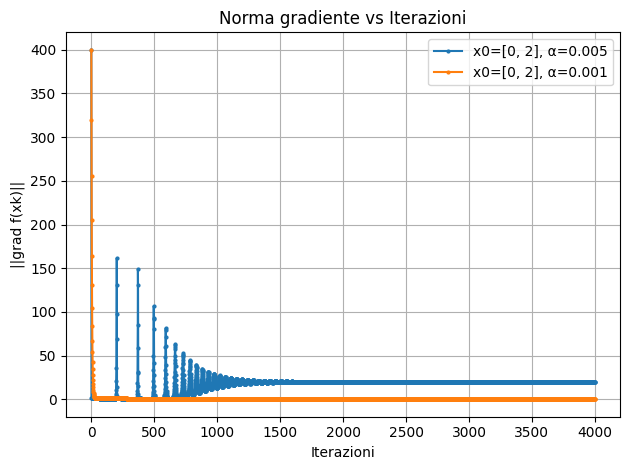

In [338]:
# Grafico norma gradiente vs iterazioni
for x0 in x0_list:
    for a in alphas:
        xk, n_iterazioni, storico_iterazioni = GD_fisso(f, df, x0, a, 4000)
        if not (np.isnan(xk[0]) or np.isnan(xk[1])):
            grad_norms = np.array(
                [np.linalg.norm(
                    [df[0](*x), 
                     df[1](*x)]
                     ) for x in storico_iterazioni])
            plt.plot(range(len(grad_norms)), grad_norms, marker="o", markersize=2, label=f"x0={x0}, α={a}")
plt.xlabel("Iterazioni")
plt.ylabel("||grad f(xk)||")
plt.title("Norma gradiente vs Iterazioni")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [339]:
def backtracking(f, x0, grad, alpha0, c=1e-4, p=0.5):
    """
    Backtracking (+ condizione di Armijo)

    Parameters:
    f (function): funzione obiettivo
    x0 (ndarray): punto corrente
    grad (list): gradiente in x0
    alpha0 (float > 0): passo iniziale
    c (float in  0,1): costante di diminuzione del passo
    p (float in 0,1): tasso di diminuzione dell'alpha ad ogni iterazione

    """
    while True:
        xk = x0.copy()
        i = 0
        for xi in x0:
            xk[i] = xi - alpha0 * grad[i]
            i += 1

        if f(*xk) <= f(*x0) - c * alpha0 * np.linalg.norm(grad)**2:
            break

        alpha0 *= p

    return alpha0
def GD_backtracking(f, df, x0, alpha0, c=1e-4, p=0.5, maxit=8000, tol_grad=1e-6, tol_diff_iter=1e-5):
    """
    Implementazione del metodo di discesa del gradiente multivariabile con passo fisso.
    
    Parameters:
    f (function): funzione obiettivo
    df (function): lista delle derivate della funzione
    x0 (ndarray): lista dei valori iniziali
    alpha0 (float > 0): passo di partenza
    c (float in  0,1): costante di diminuzione del passo
    p (float in 0,1): tasso di diminuzione dell'alpha ad ogni iterazione
    maxit (int): numero di iterazioni
    tol_grad (float): tolleranza sul gradiente
    tol_diff_iter (float): tolleranza sulla differenza di eterazione
    """
    storico_iterazioni = [x0.copy()] 
    xk = np.array(x0, float) #facciamo una copia della lista input
    for iter in range(maxit):
        grad = [g(*xk) for g in df] #lista dei valori dei gradienti gia calcolato rispetto alle incognite
        
        #controllo tolleranza sul gradiente
        if(np.linalg.norm(grad) < tol_grad): break
        
        # scelta dinamica del passo
        alpha0 = backtracking(f, x0, grad, alpha0, c, p)

        #calcoliamo x_k+1 con l'alpha giusto
        i = 0
        #cicliamo tutte le incognite
        for xi in xk: 
            #x_(k+1, i) = x_(k,i) - \alpha * (\nabla f(x_1, ... ,x_i))_i
            xk[i] = xi - alpha0 * grad[i]
            i+=1

        #controllo tolleranza sulla norma della differenza del punto attuale e di quello precedentemente calcolato
        if (np.linalg.norm(xk - x0) < tol_diff_iter): break

        x0 = xk.copy() #x_k
        storico_iterazioni.append(xk.copy())  

    return xk, alpha0, np.array(storico_iterazioni), iter #torniamo la lista finale

In [340]:
def numerical_df(f, n, eps=1e-8):
    """
    Crea lista di funzioni lambda per le derivate parziali compatibili con GD_backtracking
    che passa le variabili come *x.
    """
    df_list = []
    for i in range(n):
        # Possiamo definire la derivata rispetto a x_i = tasso di variazione di f diviso il piccolo offset ε lungo x_i
        df_list.append(
            # differenze finite in avanti
            lambda *x, i=i: (
                f(*[xi + eps if j==i else xi for j, xi in enumerate(x)]) #aggiungiamo eps solo al i-esimo componente
                - f(*x)
            ) / eps
        )
    return df_list
def OLS(A, b, n=1.0, p=2, reg=0.0, q=2):
    """
    Parametri:
    -----------
    A (ndarray): Matrice degli input.
    b (ndarray): Vettore degli output attesi.
    n (float, opzionale): Fattore scalare moltiplicativo fuori dalla norma.
    p  (float, opzionale): Potenza della norma
    reg (float, opzionale): fattore di regolarizzazione λ
    q (float, opzionale): norma della regolarizzazione
    """
    x0 = np.random.random(A.shape[1])  # punti di partenza randomici

    # funzione con regolarizzazione
    f = lambda *x: n * np.linalg.norm(A @ np.array(x) - b)**p + reg * np.linalg.norm(np.array(x))**q

    # derivate numeriche compatibili con *x
    df = numerical_df(f, A.shape[1])

    # GD_backtracking
    x_min, alpha, storico_iterazioni, iter = GD_backtracking(f, df, x0=x0, alpha0=1.0)
    return x_min, alpha, storico_iterazioni, iter 

$$f(x) = \min \| Ax - b \|_2^2 + \lambda \| x \|_2^2$$

In [341]:
n = 3
A = np.random.random((n, n))  # n * n
xstar = np.transpose(np.ones(n)) # x*= 1,...,1
b = np.dot(A, xstar)
reg = 0.5 #valore davanti \| x \|_2^2
t_norma = 2 #Ridge (L2)

In [342]:
min_x, alpha, storico_iterazioni, iter  = OLS(A, b, 0.5, 2, reg, t_norma) 
if not np.any(np.isnan(min_x)):
        print(f"{min_x}")
else:
    print(f"e) Overflow, impossibile calcolare per x0={x0}")

[0.83313369 0.52474047 0.61678426]


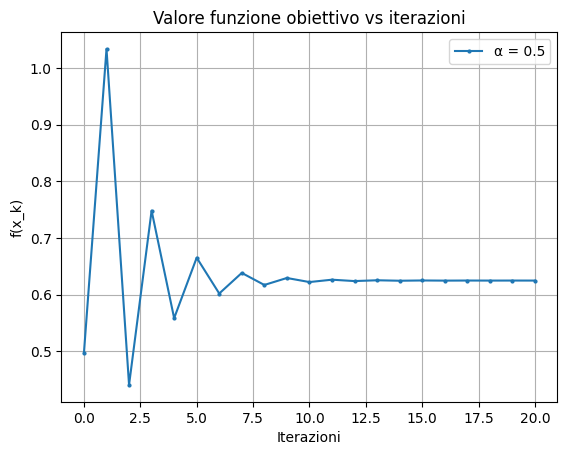

In [343]:
f_values = []
for xk in storico_iterazioni:
    val = np.linalg.norm(A @ xk - b)**2
    if np.isfinite(val):
        f_values.append(val)
    else:
        break

plt.figure()
plt.plot(
    range(len(f_values)),
    f_values,
    marker="o",
    markersize=2,
    label=f"α = {alpha}"
)
plt.xlabel("Iterazioni")
plt.ylabel("f(x_k)")
plt.title("Valore funzione obiettivo vs iterazioni")
plt.grid(True)
plt.legend()
plt.show()


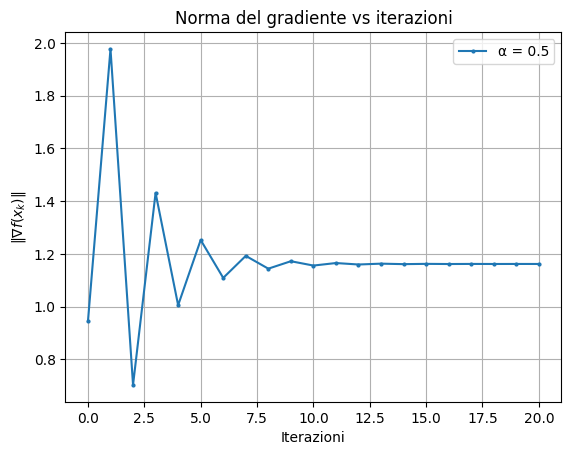

In [344]:
grad_norms = []
for xk in storico_iterazioni:
    grad = 2 * A.T @ (A @ xk - b)
    if reg != 0:
        grad += 2 * reg * xk
    grad_norms.append(np.linalg.norm(grad))

plt.figure()
plt.plot(
    range(len(grad_norms)),
    grad_norms,
    marker="o",
    markersize=2,
    label=f"α = {alpha}"
)
plt.xlabel("Iterazioni")
plt.ylabel(r"$\|\nabla f(x_k)\|$")
plt.title("Norma del gradiente vs iterazioni")
plt.grid(True)
plt.legend()
plt.show()


$$f(x) = \sum_{i=1}^n (x_i - i)^2 - \sum_{i=1}^n ln(x_i), \quad x_1 > 0$$

In [345]:
n = 10
x0 = np.full(n, 0.5)  # vettore iniziale positivo con tutti i valori 0.5F
f = lambda *x: sum((xi - i)**2 - np.log(xi) for i, xi in enumerate(x, 1))
df = numerical_df(f, n)

In [346]:
xk, a_finale, storico_iterazioni, iter  = GD_backtracking(f, df, x0, alpha0=0.01)
if not (np.isnan(xk).any()):
    print(f"x0=vec(0.5, a={a_finale}), xk[5]={xk[5]:0.6F} (valore atteso ∼6.082207)")
else:
    print(f"f) Overflow, impossibile calcolare per x0={x0}")

x0=vec(0.5, a=0.01), xk[5]=6.082068 (valore atteso ∼6.082207)


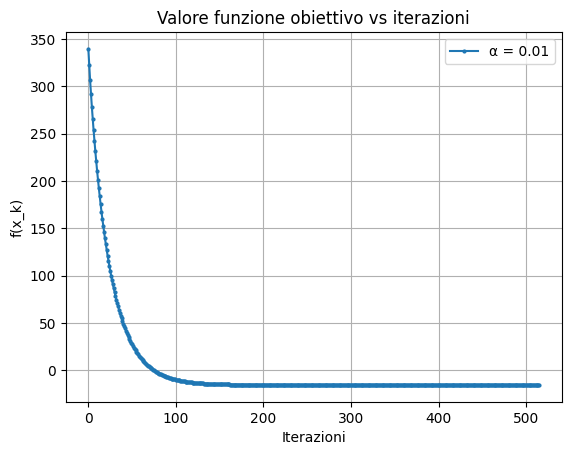

In [347]:
f_values = []
for xk in storico_iterazioni:
    val = f(*xk)
    if np.isfinite(val):
        f_values.append(val)
    else:
        break

plt.figure()
plt.plot(
    range(len(f_values)),
    f_values,
    marker="o",
    markersize=2,
    label=f"α = {a_finale}"
)
plt.xlabel("Iterazioni")
plt.ylabel("f(x_k)")
plt.title("Valore funzione obiettivo vs iterazioni")
plt.grid(True)
plt.legend()
plt.show()


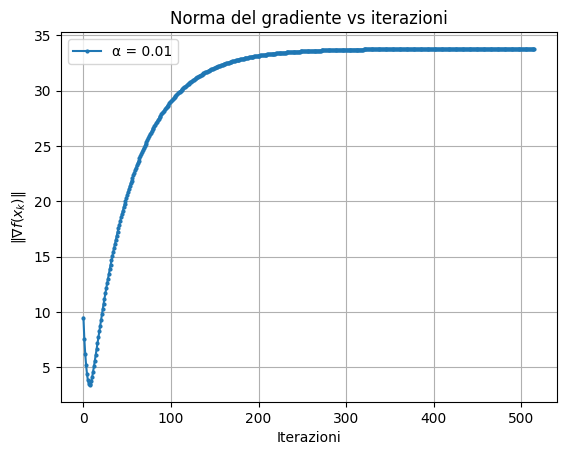

In [348]:
grad_norms = []
for xk in storico_iterazioni:
    grad = np.array([df_i(xk) for df_i in df])
    grad_norms.append(np.linalg.norm(grad))

plt.figure()
plt.plot(
    range(len(grad_norms)),
    grad_norms,
    marker="o",
    markersize=2,
    label=f"α = {a_finale}"
)
plt.xlabel("Iterazioni")
plt.ylabel(r"$\|\nabla f(x_k)\|$")
plt.title("Norma del gradiente vs iterazioni")
plt.grid(True)
plt.legend()
plt.show()


SGD su $f(x) = \sum_{i=1}^{n=10} (x_i - i)^2 - \sum_{i=1}^n ln(x_i), \quad x_1 > 0$

In [349]:
def SGD_fisso(f, df, x0, alpha, batch_size, maxit=8000, tol_grad=1e-6, tol_diff_iter=1e-5):
    """
    Implementazione del metodo del gradiente stoccastico multivariabile con passo fisso.
    
    Parameters:
    f (function): funzione obiettivo
    df (function): lista delle derivate della funzione
    x0 (ndarray): lista dei valori iniziali
    alpha (float): passo fisso
    batch_size (int): dimensione degli elementi casuali di input
    maxit (int): numero di iterazioni
    tol_grad (float): tolleranza sul gradiente
    tol_diff_iter (float): tolleranza sulla differenza di eterazione
    """
    n = len(x0)
    xk = x0.copy()
    storico_iterazioni = [xk.copy()]
    for iter in range(maxit):
        # scegli il batch
        indices = np.random.choice(n, size=batch_size, replace=False)
        grad_batch = [df[i](*xk) for i in indices]  # solo le derivate del batch
        
        # aggiorna solo gli elementi del batch
        for idx, g in zip(indices, grad_batch):
            xk[idx] = xk[idx] - alpha * g
        storico_iterazioni.append(xk.copy())
        norma2_grad = math.sqrt(sum(g**2 for g in grad_batch))
        #controllo tolleranza sul gradiente
        if(norma2_grad < tol_grad): break
        #controllo tolleranza sulla norma della differenza del punto attuale e di quello precedentemente calcolato
        if (np.linalg.norm(xk - x0) < tol_diff_iter): break
    return xk, np.array(storico_iterazioni), iter

In [350]:
batch_sizes = [0, 1, 5, 7, 10]
for b in batch_sizes:
    xk, storico_iterazioni, iter  = SGD_fisso(f, df, x0, 0.01, b)
    if not (np.isnan(xk).any()):
        print(f"b={b:4} | Iterazioni={iter:4} | xk[5]={xk[5]:4.6F} | valore atteso ∼6.082207")
    else:
        print(f"2) Overflow, impossibile calcolare per x0={x0}")

b=   0 | Iterazioni=   0 | xk[5]=0.500000 | valore atteso ∼6.082207
b=   1 | Iterazioni=5603 | xk[5]=6.082148 | valore atteso ∼6.082207
b=   5 | Iterazioni=1630 | xk[5]=6.082207 | valore atteso ∼6.082207
b=   7 | Iterazioni=1194 | xk[5]=6.082207 | valore atteso ∼6.082207
b=  10 | Iterazioni= 846 | xk[5]=6.082207 | valore atteso ∼6.082207


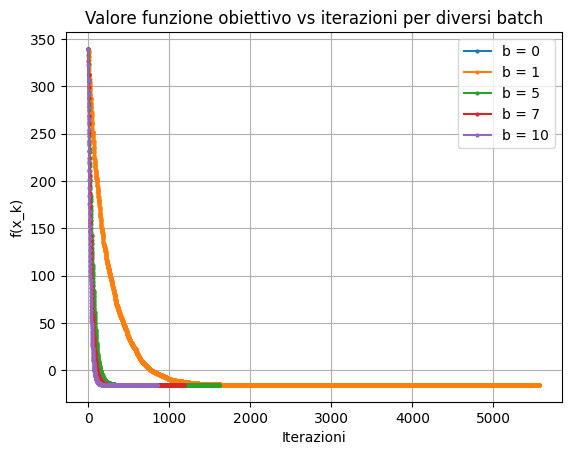

In [351]:
plt.figure()
for b in batch_sizes:
    xk, storico_iterazioni, iter = SGD_fisso(f, df, x0, 0.01, b)
    if np.isnan(xk).any():
        print(f"Overflow, impossibile calcolare per x0={x0}, b={b}")
        continue

    f_values = []
    n_cols = A.shape[1]  # Assicuro compatibilità dimensionale

    for xk_iter in storico_iterazioni:
        val = f(*xk_iter)
        if np.isfinite(val):
            f_values.append(val)
        else:
            break

    # Plot separato per ogni batch
    plt.plot(
        range(len(f_values)),
        f_values,
        marker="o",
        markersize=2,
        label=f"b = {b}"
    )

plt.xlabel("Iterazioni")
plt.ylabel("f(x_k)")
plt.title("Valore funzione obiettivo vs iterazioni per diversi batch")
plt.grid(True)
plt.legend()
plt.show()


HW 3

Esercizio 1

In [352]:
def vandermonde(x, d):
    r"""
    Preso in input un numpy array "x" di lunghezza (n, ) contentente i dati, e un valore intero "d" rappresentante il grado del polinomio, 
    costruisce e ritorna la matrice di vandermonde X di grado d, associata a x.

    Parameters:
    x (ndarray): Il vettore dei dati di input.
    d (int): Il grado massimo del polinomio.

    Returns:
    X (ndarray): La matrice di Vandermonde di grado "d", associata ad x.
    """
    n = x.shape[0]
    
    # Inizializzo la matrice di Vandermonde con shape (n, d+1)
    X = np.zeros((n, d+1))
    
    # Costruisco la matrice di Vandermonde
    for i in range(d+1):
        X[:, i] = x ** i
    return X

In [353]:
d = 3
a = np.random.randn(d+1)

n = 10
x = np.linspace(0, 1, n)

sigma = 1
e = np.random.normal(loc=0, scale=sigma, size=n)

f = lambda x, a: sum(a[k] * x**k for k in range(d+1))

y = f(x, a) + e
print("Dati rumorosi generati: ")
for i in range(n):
    print(y[i])

Dati rumorosi generati: 
-0.9649068332728696
-2.1338381448125294
-2.1767793204852275
-0.9512340758767683
-0.22144246149163738
-2.245214894350582
-0.48647557651162376
-0.9475868598207899
-0.5428110293382777
0.7681071022154085


In [354]:
def SVD(X, y):
    U, Sigma, VT =  np.linalg.svd(X, full_matrices=False)
    Sigma_inversa = np.diag(1 / Sigma)
    return VT.T @ Sigma_inversa @ U.T @ y

def residui(X, a, y):
    return np.linalg.norm(X @ a - y)

In [355]:
X = vandermonde(x, d)

a = SVD(X, y)
print(residui(X, a, y))


2.089423015858498


d=   3 | n=    10 | Redisuo=    2.300941
d=   3 | n=   100 | Redisuo=    9.831079
d=   3 | n=  1000 | Redisuo=   31.960184
d=   5 | n=    10 | Redisuo=    2.721499
d=   5 | n=   100 | Redisuo=    9.954830
d=   5 | n=  1000 | Redisuo=   30.994296
d=  10 | n=    10 | Redisuo=    0.000000
d=  10 | n=   100 | Redisuo=    8.463071
d=  10 | n=  1000 | Redisuo=   31.508653


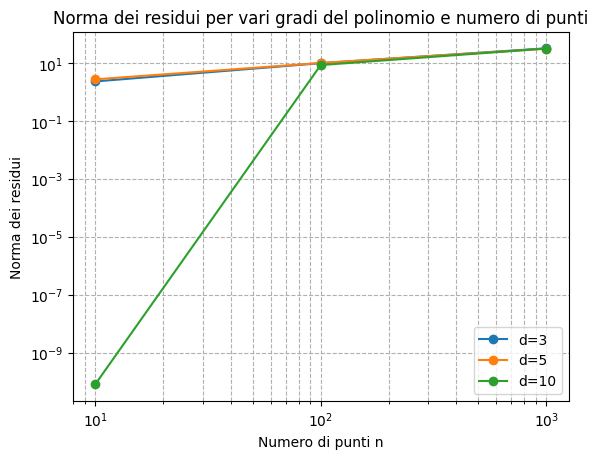

In [356]:
d_s = [3, 5, 10]
n_s = [10, 100, 1000]
for d in d_s:
    errors = []
    for n in n_s:
        a = np.random.randn(d+1)
        x = np.linspace(0, 1, n)
        sigma = 1
        e = np.random.normal(loc=0, scale=sigma, size=n)
        f = lambda x, a: sum(a[k] * x**k for k in range(d+1))
        y = f(x, a) + e
        X = vandermonde(x, d)
        a = SVD(X, y)
        err = residui(X, a, y)
        errors.append(err)
        print(f"d={d:4} | n={n:6} | Redisuo={err:12.6F}")
    plt.plot(n_s, errors, marker='o', label=f"d={d}")


plt.xlabel("Numero di punti n")
plt.ylabel("Norma dei residui")
plt.xscale("log")
plt.yscale("log")
plt.title("Norma dei residui per vari gradi del polinomio e numero di punti")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


In [357]:
df = pd.read_csv('house_partial.csv')
print(df.head())
x = df['OverallQual'].values      # input
y = df['SalePrice'].values        # target

d_s = [1, 5, 7, 9, 10]
for d in d_s:
    X = vandermonde(x, d=d)
    a = SVD(X,y)

    test_input_X = vandermonde(np.array([7]), d=d) #test OverallQual
    test_output_y = test_input_X @ a #SalePrice calcolato
    print(f"SalePrice predetto per OverallQual=7 (d={d})= {test_output_y[0]:4.8F}")

   OverallQual  SalePrice
0            7     208500
1            6     181500
2            7     223500
3            7     140000
4            8     250000
SalePrice predetto per OverallQual=7 (d=1)= 221844.53863694
SalePrice predetto per OverallQual=7 (d=5)= 207099.13360621
SalePrice predetto per OverallQual=7 (d=7)= 207012.05934956
SalePrice predetto per OverallQual=7 (d=9)= 207716.34606703
SalePrice predetto per OverallQual=7 (d=10)= -13589630.00000000


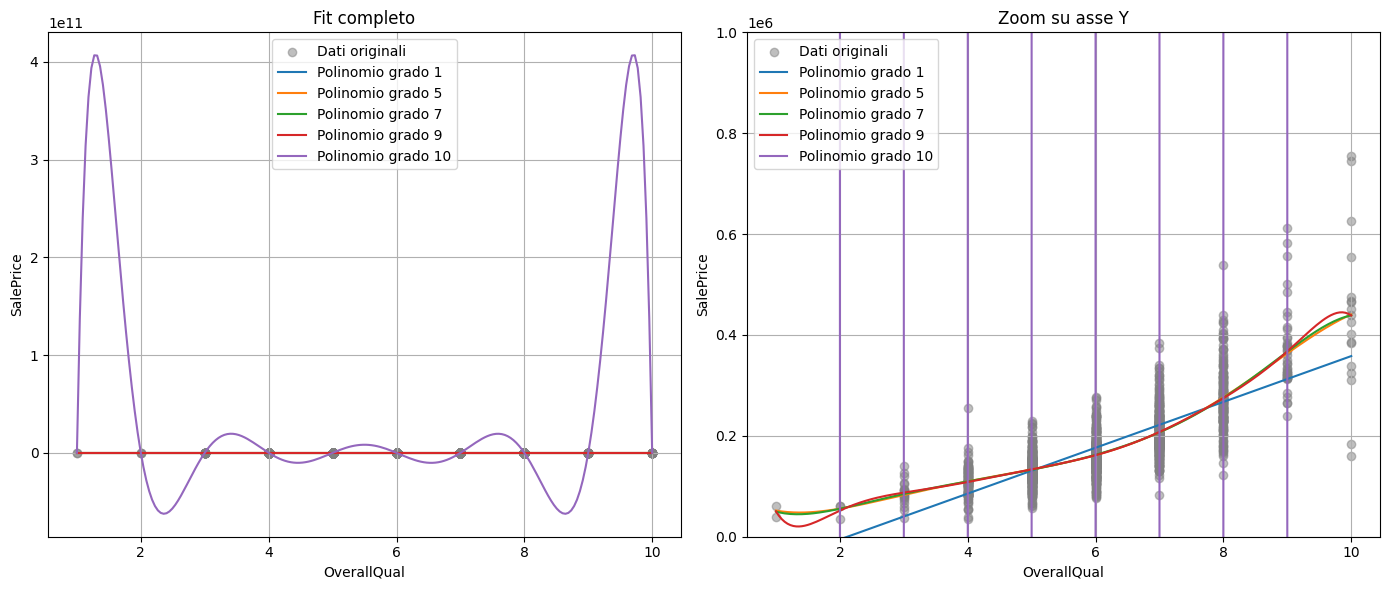

In [358]:
plt.figure(figsize=(14,6))  # figura larga per affiancare i due plot

# --- Grafico 1: completo ---
plt.subplot(1,2,1)  # 1 riga, 2 colonne, primo plot
plt.scatter(x, y, color='gray', alpha=0.5, label='Dati originali')
x_fit = np.linspace(min(x), max(x), 200)
for d in d_s:
    X = vandermonde(x, d=d)
    a = SVD(X, y)
    X_fit = vandermonde(x_fit, d=d)
    y_fit = X_fit @ a
    plt.plot(x_fit, y_fit, label=f"Polinomio grado {d}")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Fit completo")
plt.legend()
plt.grid(True)

# --- Grafico 2: zoom y limitata ---
plt.subplot(1,2,2)  # secondo plot
plt.scatter(x, y, color='gray', alpha=0.5, label='Dati originali')
for d in d_s:
    X = vandermonde(x, d=d)
    a = SVD(X, y)
    X_fit = vandermonde(x_fit, d=d)
    y_fit = X_fit @ a
    plt.plot(x_fit, y_fit, label=f"Polinomio grado {d}")
plt.ylim(0, 1000000)  # limiti dell'asse y
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Zoom su asse Y")
plt.legend()
plt.grid(True)

plt.tight_layout()  # migliora la disposizione dei due grafici
plt.show()


Esercizio 2

In [359]:
def vandermonde2d(X, d):
    """
    Costruisce una matrice Vandermonde multivariata con più features,
    aggiungendo potenze singole fino a 'degree'.
    X: array (n_samples, n_features)
    d: grado massimo dei polinomi
    """
    n_samples, n_features = X.shape
    # colonna di 1 (intercetta)
    X_poly = np.ones((n_samples, 1))
    
    # Per ogni grado
    for deg in range(1, d+1):
        # Moltiplichiamo ogni colonna di X per deg
        X_poly = np.hstack([X_poly] + [X[:, i:i+1] ** deg for i in range(n_features)])
    
    return X_poly

181687.95412169863


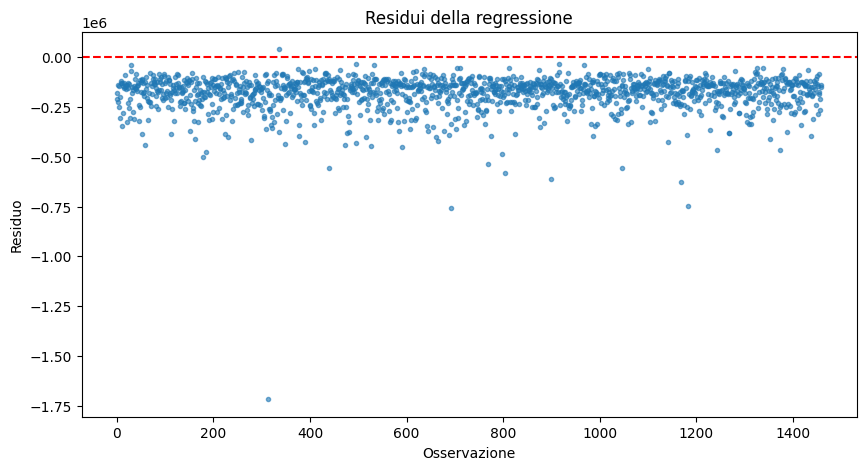

In [360]:
from sklearn.impute import SimpleImputer

# Dati
df = pd.read_csv("train.csv")
x = df.drop(columns=['SalePrice']).select_dtypes(include=np.number).values
y = df['SalePrice'].values

# Riempio i NaN con la media
x = SimpleImputer(strategy='mean').fit_transform(x)

X = vandermonde2d(x, d=20)

a = SVD(X, y)
err = (X @ a - y)
print(np.mean(np.abs(err)))

# Grafico residui
plt.figure(figsize=(10,5))
plt.plot(err, marker='o', linestyle='', markersize=3, alpha=0.6)
plt.xlabel('Osservazione')
plt.ylabel('Residuo')
plt.title('Residui della regressione')
plt.axhline(0, color='red', linestyle='--')  # linea zero
plt.show()



In [361]:
results = []
feature_names = df.drop(columns=['SalePrice']).select_dtypes(include=np.number).columns.tolist()
for i in range(x.shape[1]):
    # crea una copia di x senza la i-esima feature
    x_subset = np.delete(x, i, axis=1)
    
    # trasformazione Vandermonde
    X_subset = vandermonde2d(x_subset, d=d)
    
    # calcolo coefficienti con SVD
    a = SVD(X_subset, y)
    
    # errore residuo
    err = X_subset @ a - y
    mse = np.mean(err**2)
    # R^2
    r2 = 1 - np.sum((y - X_subset @ a)**2) / np.sum((y - y.mean())**2)
    results.append((feature_names[i], mse, r2))
    #print(f"Rimossa feature {i:3} | MSE = {mse:3.2f}")

# Ordina le feature per impatto sull'errore
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
print("\nOrdine di importanza delle feature:")
for name, mse, r2 in results_sorted:
    print(f"{name:15} | MSE = {mse:8.2f} | R2 = {r2:.4f}")


Ordine di importanza delle feature:
LotArea         | MSE = 409445250711.19 | R2 = -63.9214
GarageYrBlt     | MSE = 84638155136.41 | R2 = -12.4202
GarageArea      | MSE = 81015385055.21 | R2 = -11.8457
Fireplaces      | MSE = 74278415071.69 | R2 = -10.7775
1stFlrSF        | MSE = 72461238960.80 | R2 = -10.4894
MasVnrArea      | MSE = 66095334444.04 | R2 = -9.4800
PoolArea        | MSE = 65164748857.50 | R2 = -9.3325
GrLivArea       | MSE = 59613985197.14 | R2 = -8.4524
OverallQual     | MSE = 57167781775.67 | R2 = -8.0645
YearBuilt       | MSE = 56682268664.77 | R2 = -7.9875
FullBath        | MSE = 55941976793.08 | R2 = -7.8701
YearRemodAdd    | MSE = 52352876269.42 | R2 = -7.3010
2ndFlrSF        | MSE = 50105516769.36 | R2 = -6.9447
OverallCond     | MSE = 49136885514.16 | R2 = -6.7911
TotRmsAbvGrd    | MSE = 45897779006.88 | R2 = -6.2775
MSSubClass      | MSE = 40792557324.62 | R2 = -5.4680
BedroomAbvGr    | MSE = 40651764589.95 | R2 = -5.4457
GarageCars      | MSE = 39231027920.44 

HW 4

In [362]:
file = "./gatto.png"
img = Image.open(file).convert("L") # L = grayscale
A = np.array(img) #m*n
m, n = A.shape[:2]  # prende solo le prime due dimensioni
print("m =", m)
print("n =", n)

m = 5348
n = 3000


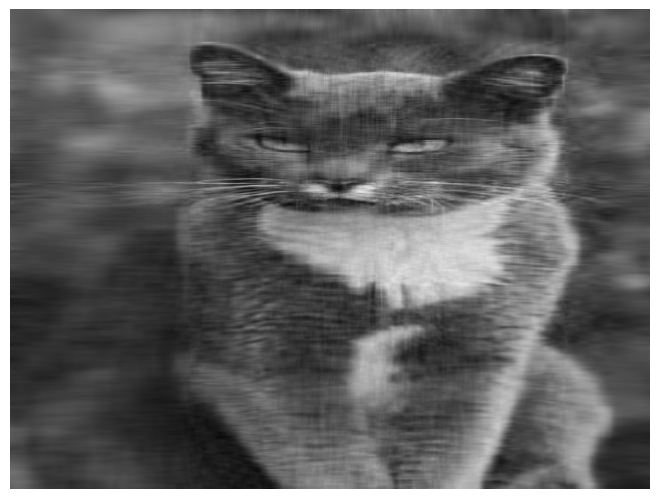

In [363]:
U, S, VT = np.linalg.svd(A, full_matrices=False)
p = 30
if (p > np.linalg.matrix_rank(A)):
    raise ValueError("p <= rk(A)")

Ap = np.zeros_like(A, dtype=float) #m*n
for i in range(p):
    u_i = U[:, i].reshape(-1, 1)     #colonna m*1
    v_i = VT[i, :].reshape(1, -1)    #riga 1*n
    sigma_i = S[i]
    Ap += sigma_i * u_i @ v_i

plt.imshow(Ap, cmap='gray', aspect='auto')
plt.axis('off')                        # rimuove assi
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # elimina margini
plt.show()

In [364]:
#salvataggi su disco senza bordo
Ap_uint8 = np.clip(Ap, 0, 255).astype(np.uint8)  
img_out = Image.fromarray(Ap_uint8)
img_out.save("compresso.png")

In [365]:
errore_relativo = np.linalg.norm(A - Ap) / np.linalg.norm(A)
print(f"Errore relativo: {errore_relativo:.4f} ({errore_relativo*100:.2f}%)")

Errore relativo: 0.1511 (15.11%)


In [366]:
dimensione_originale = os.path.getsize(file)
dimensione_compresso = os.path.getsize("compresso.png")
print(f"Dimensione original e: {dimensione_originale / 1024:.2f} KB")
print(f"Dimensione compressa: {dimensione_compresso / 1024:.2f} KB")

risparmio = 100 * (dimensione_originale - dimensione_compresso) / dimensione_originale
print(f"Risparmio: {risparmio:.2f}%")

Dimensione original e: 9460.15 KB
Dimensione compressa: 3982.94 KB
Risparmio: 57.90%


In [367]:
Cp = (1/p * min(m,n)) - 1
print(f"Fattore di compressione: {Cp}")

Fattore di compressione: 99.0


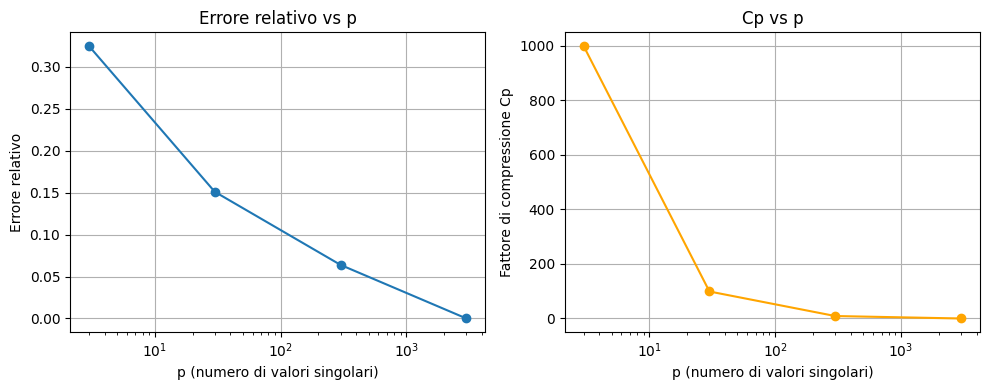

In [368]:
errore_relativo_list = []
Cp_list = []

p_s = [3,30, 300, 3000]
for p in p_s:
    if (p > np.linalg.matrix_rank(A)):
        raise ValueError("p <= rk(A)")

    Ap = np.zeros_like(A, dtype=float) #m*n
    for i in range(p):
        u_i = U[:, i].reshape(-1, 1)     #colonna m*1
        v_i = VT[i, :].reshape(1, -1)    #riga 1*n
        sigma_i = S[i]
        Ap += sigma_i * u_i @ v_i
    errore_relativo_list.append(np.linalg.norm(A - Ap) / np.linalg.norm(A))
    Cp_list.append((1/p * min(m,n)) - 1)

# Primo grafico: errore relativo
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(p_s, errore_relativo_list, marker='o', linestyle='-')
plt.xlabel("p (numero di valori singolari)")
plt.ylabel("Errore relativo")
plt.title("Errore relativo vs p")
plt.grid(True)
plt.xscale("log")  # scala log perché p varia molto
plt.yscale("linear")

# Secondo grafico: Cp
plt.subplot(1,2,2)
plt.plot(p_s, Cp_list, marker='o', color='orange', linestyle='-')
plt.xlabel("p (numero di valori singolari)")
plt.ylabel("Fattore di compressione Cp")
plt.title("Cp vs p")
plt.grid(True)
plt.xscale("log")
plt.yscale("linear")

plt.tight_layout()
plt.show()

Es 2

In [369]:
x=color.rgb2gray(plt.imread("persone.jpg"))

# Normalizzazione (nel range [0, 1])
x = x / x.max()

# Definizione kernel di blur e operatore associato
kernel = utilities.gaussian2d_kernel(k=11, sigma=3.5)
A = operators.ConvolutionOperator(kernel)

y = A(x) #immagine solo blur
y_delta = y + utilities.gaussian_noise(y, noise_level=0.05) #blur + noise

# CGLS
cgls_solver = solvers.CGLS(A)

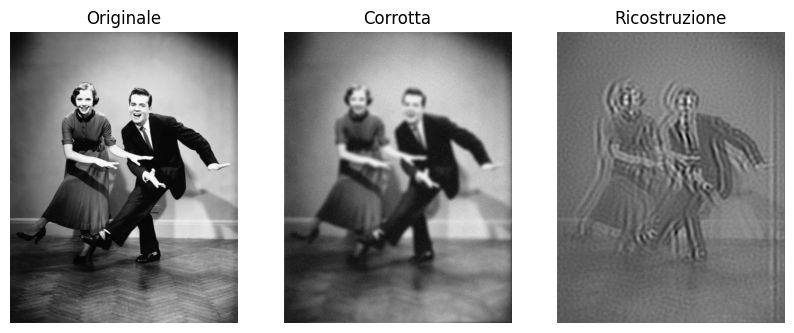

In [370]:
x0 = np.zeros_like(x)
kmax = 30
tolf = 1e-8
tolx = 1e-8
x_cgls = cgls_solver.solve(y_delta, x0, kmax, tolf, tolx)

# Visualizzazione ricostruzione
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(x, cmap="gray")
plt.title("Originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(y_delta, cmap="gray")
plt.axis("off")
plt.title("Corrotta")

plt.subplot(1, 3, 3)
plt.imshow(x_cgls, cmap="gray")
plt.axis("off")
plt.title("Ricostruzione")
plt.show()
plt.close()

In [371]:
# Lettura dei dati da skimage
x = data.moon()
x = x / x.max()

kernel = utilities.gaussian2d_kernel(k=11, sigma=3.5)
A = operators.ConvolutionOperator(kernel)
y = A(x) #blur
w = utilities.gaussian_noise(y, noise_level=0.05) #rumore statico
y_delta = y + w #immagina blur + rumore
delta = np.linalg.norm(w)


L = operators.Identity()
lambdas = np.logspace(-4, 1, 20) 
DP_found = []
solutions = []
for lmbda in lambdas:
    M = operators.TikhonovOperator(A, L, lmbda)

    # Definizione dati estesi ybar e ybar_delta
    ybar = np.pad(y, ((0, 512), (0, 0)))
    ybar_delta = np.pad(y_delta, ((0, 512), (0, 0)))

    cgls_tik_solver = solvers.CGLS(M)

    x0 = np.zeros_like(x)
    kmax = 30
    tolf = 1e-8
    tolx = 1e-8
    #OLS regolarizzata
    x_tik = cgls_tik_solver.solve(ybar_delta, x0, kmax, tolf, tolx)
    
    solutions.append(x_tik) 
    dp = np.linalg.norm(A(x_tik) - y_delta) #residuo della soluzione
    DP_found.append(dp)
    print(f"lmbda = {lmbda:4.5F} | DP-delta = {abs(dp-delta):3.5F}")

best_idx = np.argmin(np.abs(np.array(DP_found) - delta))
best_lambda_DP = lambdas[best_idx]
print(f"Lambda che minimizza DP: {best_lambda_DP}")

lmbda = 0.00010 | DP-delta = 1.21755
lmbda = 0.00018 | DP-delta = 1.21755
lmbda = 0.00034 | DP-delta = 1.21755
lmbda = 0.00062 | DP-delta = 1.21755
lmbda = 0.00113 | DP-delta = 1.21755
lmbda = 0.00207 | DP-delta = 1.21754
lmbda = 0.00379 | DP-delta = 1.21739
lmbda = 0.00695 | DP-delta = 1.21589
lmbda = 0.01274 | DP-delta = 1.20195
lmbda = 0.02336 | DP-delta = 1.11279
lmbda = 0.04281 | DP-delta = 0.83651
lmbda = 0.07848 | DP-delta = 0.43006
lmbda = 0.14384 | DP-delta = 0.61117
lmbda = 0.26367 | DP-delta = 7.15319
lmbda = 0.48329 | DP-delta = 33.05800
lmbda = 0.88587 | DP-delta = 88.97964
lmbda = 1.62378 | DP-delta = 153.34817
lmbda = 2.97635 | DP-delta = 192.56399
lmbda = 5.45559 | DP-delta = 208.14476
lmbda = 10.00000 | DP-delta = 213.25496
Lambda che minimizza DP: 0.07847599703514607


Errore relativo = 10.53%


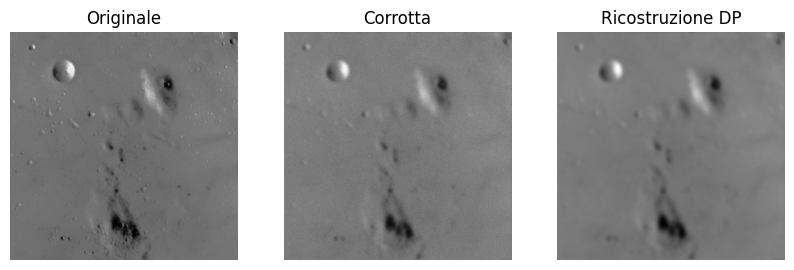

In [372]:
print(f"Errore relativo = {utilities.rel_err(solutions[best_idx], x)*100:3.2F}%")

# Visualizzazione ricostruzione
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(x, cmap="gray")
plt.title("Originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(y_delta, cmap="gray")
plt.axis("off")
plt.title("Corrotta")

plt.subplot(1, 3, 3)
plt.imshow(x_tik, cmap="gray")
plt.axis("off")
plt.title("Ricostruzione DP")
plt.show()

In [373]:
errore_assoluto_found = []
for x_tik, lmbda in zip(solutions, lambdas):
    errore_assoluto = np.linalg.norm(x - x_tik)
    errore_assoluto_found.append(errore_assoluto)
    print(f"lmbda = {lmbda:4.5F} | Errore assoluto = {abs(errore_assoluto):3.5F}")

best_idx = np.argmin(np.abs(errore_assoluto_found))
best_lambda_Ea = lambdas[best_idx]
print(f"Lambda che minimizza errore assoluto: {best_lambda_Ea}")

lmbda = 0.00010 | Errore assoluto = 133.63994
lmbda = 0.00018 | Errore assoluto = 133.63719
lmbda = 0.00034 | Errore assoluto = 133.62796
lmbda = 0.00062 | Errore assoluto = 133.59695
lmbda = 0.00113 | Errore assoluto = 133.49288
lmbda = 0.00207 | Errore assoluto = 133.14443
lmbda = 0.00379 | Errore assoluto = 131.98721
lmbda = 0.00695 | Errore assoluto = 128.24537
lmbda = 0.01274 | Errore assoluto = 117.12178
lmbda = 0.02336 | Errore assoluto = 90.90446
lmbda = 0.04281 | Errore assoluto = 52.76295
lmbda = 0.07848 | Errore assoluto = 23.87711
lmbda = 0.14384 | Errore assoluto = 12.35019
lmbda = 0.26367 | Errore assoluto = 16.92349
lmbda = 0.48329 | Errore assoluto = 43.71932
lmbda = 0.88587 | Errore assoluto = 100.08054
lmbda = 1.62378 | Errore assoluto = 164.59352
lmbda = 2.97635 | Errore assoluto = 203.85465
lmbda = 5.45559 | Errore assoluto = 219.44927
lmbda = 10.00000 | Errore assoluto = 224.56363
Lambda che minimizza errore assoluto: 0.14384498882876628


Errore relativo = 5.45%


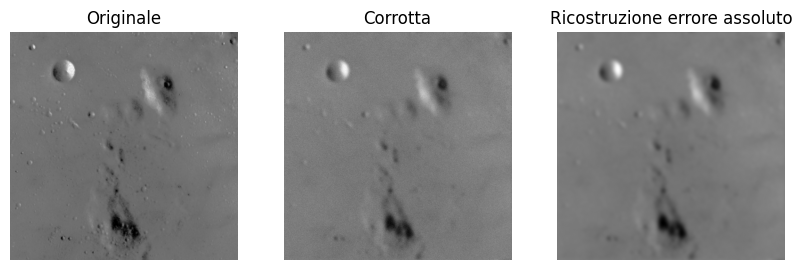

In [374]:
print(f"Errore relativo = {utilities.rel_err(solutions[best_idx], x)*100:3.2F}%")

# Visualizzazione ricostruzione
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(x, cmap="gray")
plt.title("Originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(y_delta, cmap="gray")
plt.axis("off")
plt.title("Corrotta")

plt.subplot(1, 3, 3)
plt.imshow(x_tik, cmap="gray")
plt.axis("off")
plt.title("Ricostruzione errore assoluto")
plt.show()

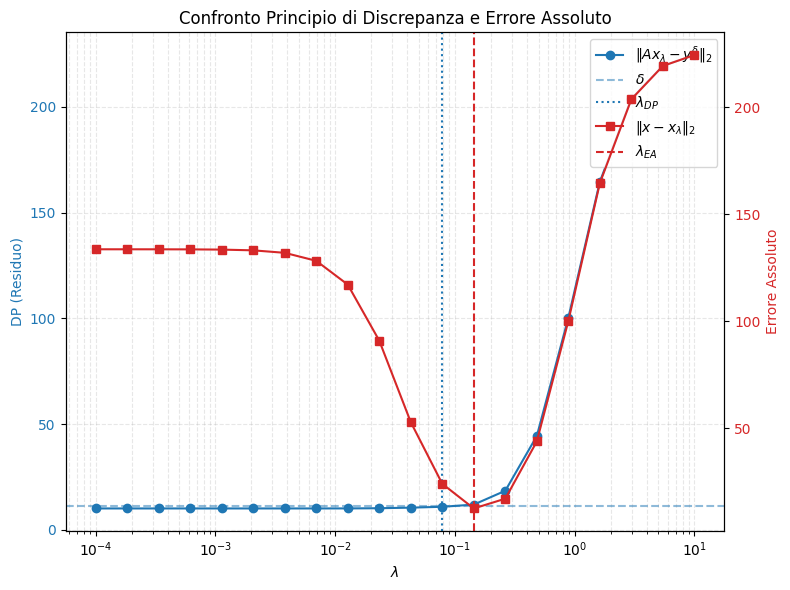

In [375]:
DP_found = np.array(DP_found)
errore_assoluto_found = np.array(errore_assoluto_found)

fig, ax1 = plt.subplots(figsize=(8,6))

# --- Curva DP sul primo asse y ---
ax1.semilogx(lambdas, DP_found, '-o', color='tab:blue', label=r'$\|Ax_\lambda - y^\delta\|_2$')
ax1.axhline(delta, color='tab:blue', linestyle='--', alpha=0.5, label=r'$\delta$')
ax1.set_xlabel(r'$\lambda$')
ax1.set_ylabel('DP (Residuo)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, which="both", ls="--", alpha=0.3)

# Linea verticale lambda ottimo DP
ax1.axvline(best_lambda_DP, color='tab:blue', linestyle=':', label=rf'$\lambda_{{DP}}$')

# --- Curva Errore Assoluto sul secondo asse y ---
ax2 = ax1.twinx()
ax2.semilogx(lambdas, errore_assoluto_found, '-s', color='tab:red', label=r'$\|x - x_\lambda\|_2$')
ax2.set_ylabel('Errore Assoluto', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Linea verticale lambda ottimo Errore Assoluto
ax2.axvline(best_lambda_Ea, color='tab:red', linestyle='--', label=rf'$\lambda_{{EA}}$')

# --- Legenda combinata ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Confronto Principio di Discrepanza e Errore Assoluto')
plt.tight_layout()
plt.show()


Errore relativo:  4.2%


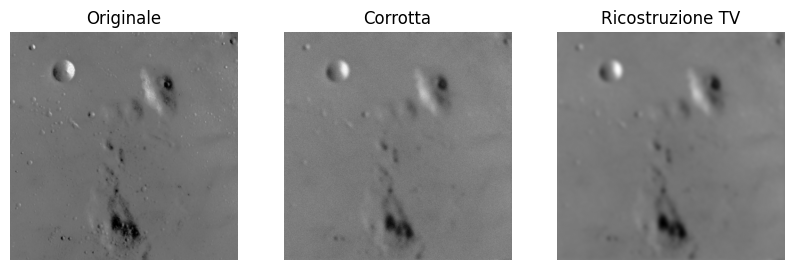

In [376]:
gd_tv_solver = solvers.GDTotalVariation(A, beta=1e-3)

# Scelta parametri TV (beta e lambda)
lmbda = 1

# Scelta di x0, kmax, tolf, tolx
x0 = np.zeros_like(x)
kmax = 30
tolf = 1e-8
tolx = 1e-8

# Soluzione
x_TV, obj_val, grad_norm = gd_tv_solver.solve(y_delta, lmbda, x0, kmax, tolf, tolx)

print(f"Errore relativo: {utilities.rel_err(x_TV,x)*100:4.2}%")

# Visualizzazione ricostruzione
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(x, cmap="gray")
plt.title("Originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(y_delta, cmap="gray")
plt.axis("off")
plt.title("Corrotta")

plt.subplot(1, 3, 3)
plt.imshow(x_TV, cmap="gray")
plt.axis("off")
plt.title("Ricostruzione TV")
plt.show()

In [377]:
# Scelta di x0, kmax, tolf, tolx
x0 = np.zeros_like(x)
kmax = 30
tolf = 1e-8
tolx = 1e-8

lambdas = np.logspace(-4, 0, 20) 
errore_assoluto_found = []
for lmbda in lambdas:
    x_TV_lmbda, obj_val, grad_norm = gd_tv_solver.solve(y_delta, lmbda, x0, kmax, tolf, tolx)
    errore_assoluto = np.linalg.norm(x - x_TV_lmbda)
    errore_assoluto_found.append((errore_assoluto, x_TV_lmbda))   
    print(f"lmbda = {lmbda:4.5F} | Errore assoluto = {abs(errore_assoluto):3.5F}")

best_idx = np.argmin([e[0] for e in errore_assoluto_found])
best_lambda_Ea = lambdas[best_idx]
print(f"Lambda che minimizza errore assoluto per TV: {best_lambda_Ea}")

lmbda = 0.00010 | Errore assoluto = 10.19735
lmbda = 0.00016 | Errore assoluto = 10.22901
lmbda = 0.00026 | Errore assoluto = 10.31030
lmbda = 0.00043 | Errore assoluto = 9.26733
lmbda = 0.00070 | Errore assoluto = 8.34827
lmbda = 0.00113 | Errore assoluto = 8.16583
lmbda = 0.00183 | Errore assoluto = 8.13338
lmbda = 0.00298 | Errore assoluto = 8.24006
lmbda = 0.00483 | Errore assoluto = 8.45863


KeyboardInterrupt: 

Errore relativo = 3.58%


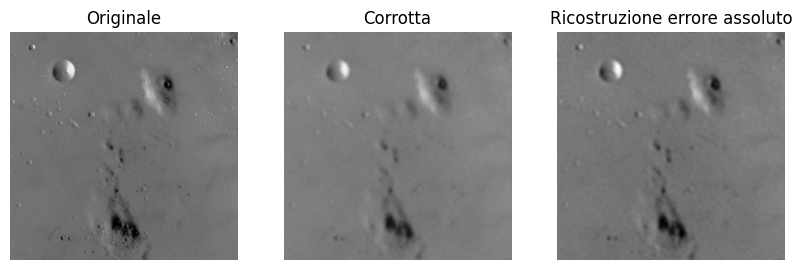

In [ ]:
print(f"Errore relativo = {utilities.rel_err(errore_assoluto_found[best_idx][1], x)*100:3.2f}%")

# Visualizzazione ricostruzione
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(x, cmap="gray")
plt.title("Originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(y_delta, cmap="gray")
plt.axis("off")
plt.title("Corrotta")

plt.subplot(1, 3, 3)
plt.imshow(errore_assoluto_found[best_idx][1], cmap="gray")
plt.axis("off")
plt.title("Ricostruzione errore assoluto")
plt.show()

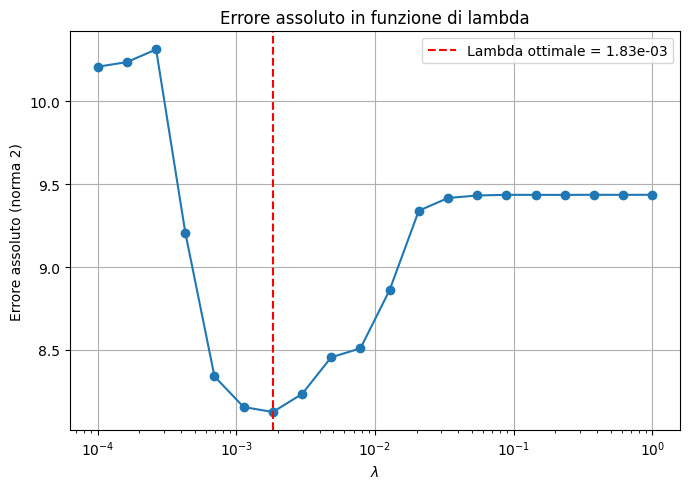

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(lambdas, [e[0] for e in errore_assoluto_found], marker='o')
plt.xscale('log')
plt.xlabel(r'$\lambda$')
plt.ylabel('Errore assoluto (norma 2)')
plt.title('Errore assoluto in funzione di lambda')
plt.grid(True)
plt.axvline(best_lambda_Ea, color='r', linestyle='--', label=f'Lambda ottimale = {best_lambda_Ea:.2e}')
plt.legend()
plt.tight_layout()
plt.show()

Rumore=0.010: 
	PSF=(Kernel size=9, sigma=2.0):
		Max iterazioni=20:
			CGLS Er = 4.10% | Tikhonov Er=3.25% | TV Er=3.02%
		Max iterazioni=50:
			CGLS Er = 20.31% | Tikhonov Er=3.94% | TV Er=3.02%
		Max iterazioni=150:
			CGLS Er = 59.82% | Tikhonov Er=3.93% | TV Er=3.02%
	PSF=(Kernel size=15, sigma=4.0):
		Max iterazioni=20:
			CGLS Er = 3.79% | Tikhonov Er=3.44% | TV Er=4.04%
		Max iterazioni=50:
			CGLS Er = 17.89% | Tikhonov Er=4.02% | TV Er=4.04%
		Max iterazioni=150:
			CGLS Er = 45.36% | Tikhonov Er=4.02% | TV Er=4.04%
Rumore=0.050: 
	PSF=(Kernel size=9, sigma=2.0):
		Max iterazioni=20:
			CGLS Er = 22.05% | Tikhonov Er=7.29% | TV Er=3.39%
		Max iterazioni=50:
			CGLS Er = 110.49% | Tikhonov Er=7.33% | TV Er=3.38%
		Max iterazioni=150:
			CGLS Er = 300.96% | Tikhonov Er=7.30% | TV Er=3.38%
	PSF=(Kernel size=15, sigma=4.0):
		Max iterazioni=20:
			CGLS Er = 23.99% | Tikhonov Er=5.40% | TV Er=4.13%
		Max iterazioni=50:
			CGLS Er = 96.91% | Tikhonov Er=5.43% | TV Er=4.12%
		Max it

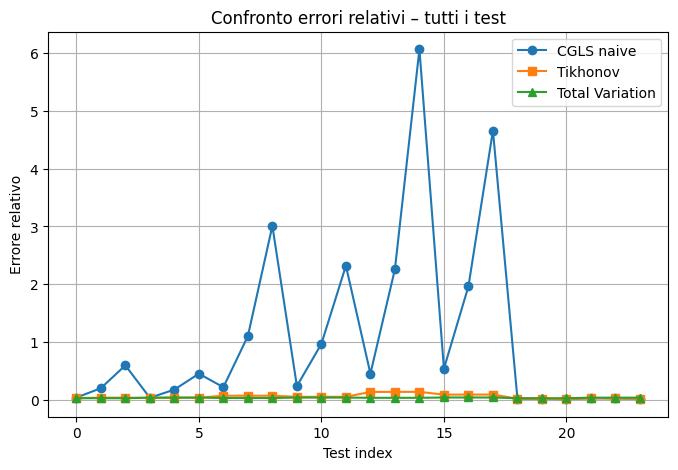

In [378]:
# Ripetiamo i vari test

# Lettura dei dati da skimage
x = data.moon()
x = x / x.max()
norm_x = np.linalg.norm(x)

noise_levels = [0.01, 0.05, 0.1, 0]
psf_list = [(9, 2.0), (15, 4.0)]   # (k, sigma)
kmax_list = [20, 50, 150]

x0 = np.zeros_like(x)
tolf = 1e-8
tolx = 1e-8

lambdas = np.logspace(-2, 1, 10)

# Liste per il grafico finale
errrel_cgls_all = []
errrel_tik_all  = []
errrel_tv_all   = []

for noise_level in noise_levels:
    print(f"Rumore={noise_level:.3f}: ")
    for kernel_size, sigma in psf_list:
        print(f"\tPSF=(Kernel size={kernel_size}, sigma={sigma}):")
        for k_max in kmax_list:
            print(f"\t\tMax iterazioni={k_max}:")
            # 1) crea y_delta
            kernel = utilities.gaussian2d_kernel(kernel_size, sigma)
            A = operators.ConvolutionOperator(kernel)
            y = A(x)
            w = utilities.gaussian_noise(y, noise_level)
            y_delta = y + w
            delta = np.linalg.norm(w)

            # 2) CGLS naive
            x_cgls = solvers.CGLS(A).solve(y_delta, x0, k_max, tolf, tolx)
            errrel_cgls = np.linalg.norm(x_cgls - x) / norm_x
            print(f"\t\t\tCGLS Er = {errrel_cgls*100:.2f}% |", end=" ")

            # 3) Tikhonov con DP
            L = operators.Identity()
            solutions = []
            residuals = []
            for lmbda in lambdas:
                M = operators.TikhonovOperator(A, L, lmbda)
                cgls_tik_solver = solvers.CGLS(M)
                
                # Manteniamo il padding come nel tuo codice
                ybar = np.pad(y, ((0, 512), (0, 0)))
                ybar_delta = np.pad(y_delta, ((0, 512), (0, 0)))
                
                # Risoluzione CGLS sul TikhonovOperator
                x_tik = cgls_tik_solver.solve(ybar_delta, x0, k_max, tolf, tolx)

                solutions.append(x_tik)
                # residuo rispetto a y_delta originale
                residuals.append(np.linalg.norm(A(x_tik) - y_delta))

            # Selezione lambda tramite DP
            best_idx = np.argmin(np.abs(np.array(residuals) - delta))
            #lmbda_DP = lambdas[best_idx]
            x_tik_DP = solutions[best_idx]
            errrel_tik = np.linalg.norm(x_tik_DP - x) / norm_x
            print(f"Tikhonov Er={errrel_tik*100:.2f}% |", end=" ")

            # 4) Total Variation
            gd_tv_solver = solvers.GDTotalVariation(A, beta=1e-3)
            errors_tv = []
            for lmbda in lambdas:
                x_TV, _, _ = gd_tv_solver.solve(
                    y_delta, lmbda, x0, k_max, tolf, tolx
                )
                errors_tv.append(np.linalg.norm(x_TV - x) / norm_x)

            errrel_tv = min(errors_tv)
            print(f"TV Er={errrel_tv*100:.2f}%")


            #5) Salvataggio per grafico
            errrel_cgls_all.append(errrel_cgls)
            errrel_tik_all.append(errrel_tik)
            errrel_tv_all.append(errrel_tv)
plt.figure(figsize=(8,5))
plt.plot(errrel_cgls_all, 'o-', label='CGLS naive')
plt.plot(errrel_tik_all,  's-', label='Tikhonov')
plt.plot(errrel_tv_all,   '^-', label='Total Variation')

plt.xlabel('Test index')
plt.ylabel('Errore relativo')
plt.title('Confronto errori relativi – tutti i test')
plt.legend()
plt.grid(True)
plt.show()
